# Detección Avanzada de Anomalías y Ruido

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/07_deteccion_avanzada_anomalias.ipynb)


## Objetivos


- Comprender la limitación de las técnicas estadísticas univariadas (como el Boxplot o Z-Score) en espacios de alta dimensionalidad.
- Desarrollar la intuición geométrica detrás de la detección de anomalías multivariadas.
- Utilizar *Isolation Forest* como herramienta de exploración de datos para identificar *outliers* ocultos.
- Diferenciar entre una "anomalía" (información valiosa/rara) y "ruido puro" (ausencia de información), evaluando su impacto en el *dataset*.



## Prerrequisitos


- [Introducción al EDA y Calidad de Datos](01_introduccion_eda.ipynb) (Concepto de *Outlier* univariado).
- [Reducción de Dimensionalidad (PCA)](06_reduccion_dimensionalidad_pca.ipynb) (Concepto de espacio multidimensional).

---

## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings('ignore')

## Introducción Teórica


En el primer *notebook* de este capítulo, aprendimos a usar diagramas de caja (*Boxplots*) para encontrar valores atípicos. Esa técnica es excelente, pero tiene un defecto fatal: **es ciega a las relaciones entre variables**.

Imaginemos el funcionamiento del sistema de seguridad de un banco:
- Un cliente que transfiere \$500 no es una anomalía (es un monto normal).
- Un cliente que hace una transferencia a las 3:00 AM no es una anomalía (hay gente nocturna).
- Pero un cliente que transfiere \$500 a las 3:00 AM desde un país extranjero... **es una anomalía masiva**.

Si analizamos el "Monto", la "Hora" y el "País" por separado (univariado), todo parece normal. La anomalía solo existe en la **intersección multidimensional** de esas variables.

## 1. El *Outlier* Invisible (Limitación Univariada)


Vamos a simular un *dataset* de sensores industriales. Tenemos la Temperatura y la Vibración de un motor. Existe una fuerte relación lineal entre ambas: a mayor temperatura, mayor vibración.

Inyectamos un punto defectuoso (anomalía) y vemos si las herramientas clásicas pueden detectarlo.

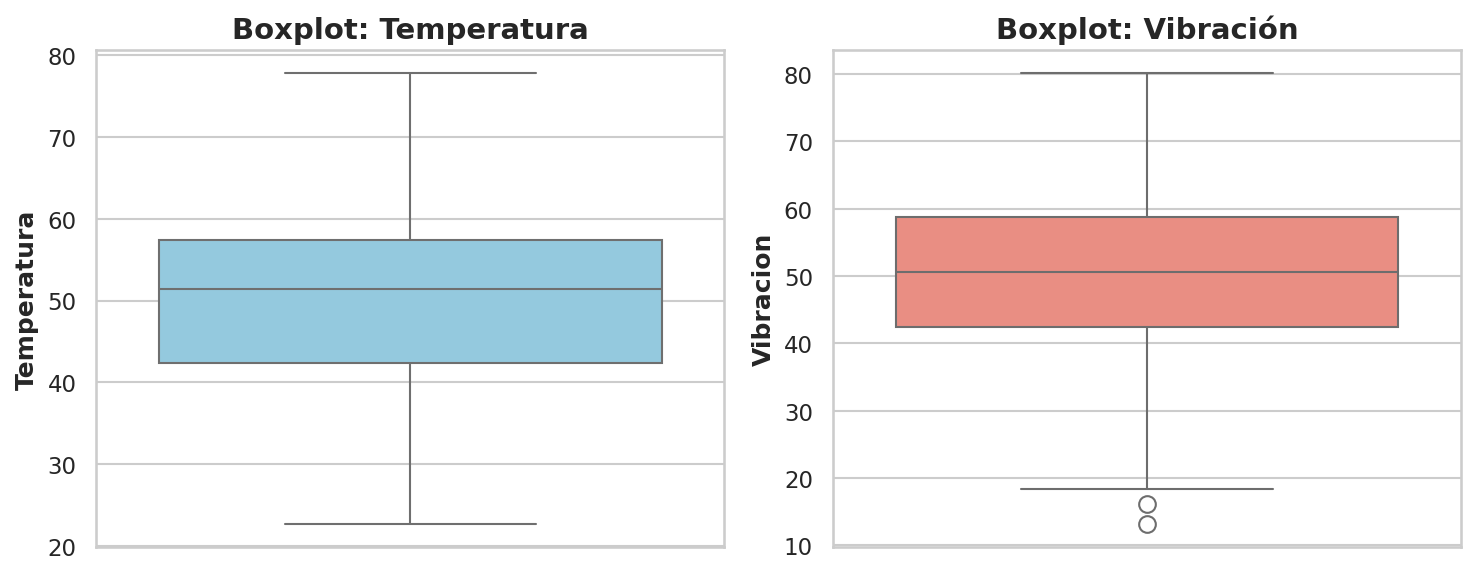

In [14]:
# Generamos datos normales correlacionados
np.random.seed(101)
temperatura = np.random.normal(50, 10, 300)
vibracion = temperatura + np.random.normal(0, 5, 300)

# Inyectamos una anomalía manual
# Temperatura baja (30) pero Vibración altísima (80)
temperatura = np.append(temperatura, 30)
vibracion = np.append(vibracion, 80)

df_motor = pd.DataFrame({'Temperatura': temperatura, 'Vibracion': vibracion})

# Visualizamos con Boxplots (Univariado)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_motor['Temperatura'], ax=axes[0], color='skyblue').set_title('Boxplot: Temperatura')
sns.boxplot(y=df_motor['Vibracion'], ax=axes[1], color='salmon').set_title('Boxplot: Vibración')
plt.tight_layout()
plt.show()


**Análisis de Ingeniería:**

Observar los *boxplots*. Prácticamente, no hay puntos fuera de los bigotes. El valor de Temperatura (30) es perfectamente normal. El valor de Vibración (80) es alto, pero está dentro del rango aceptable de la distribución general. **La estadística univariada nos dice que el motor está sano.**

¿Qué pasa si miramos ambas variables al mismo tiempo?

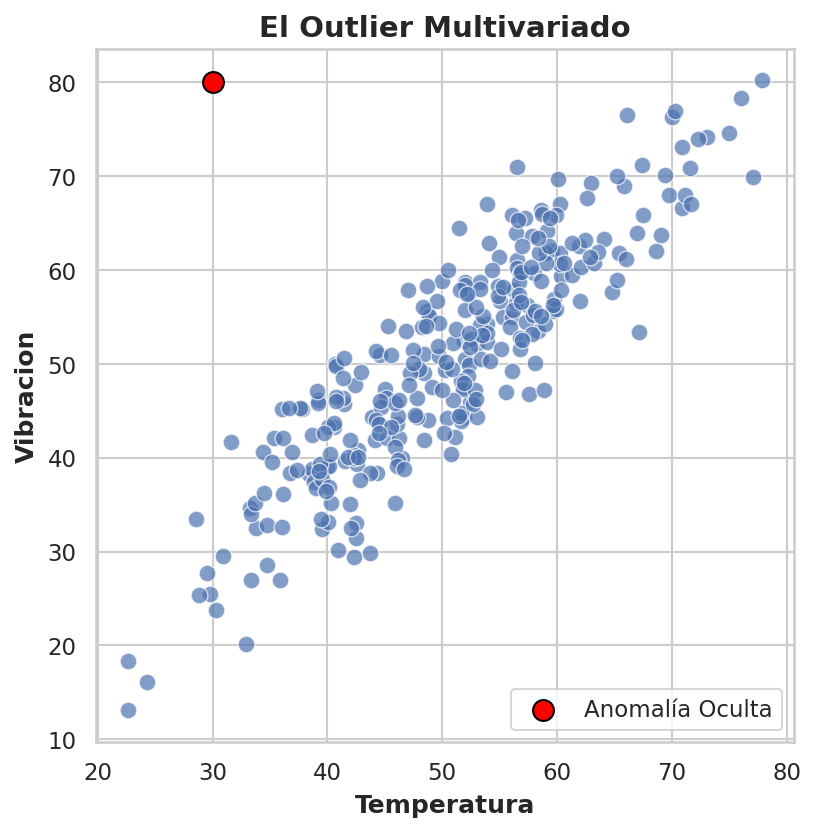

In [15]:
# Visualizamos en 2D (Multivariado)
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_motor, x='Temperatura', y='Vibracion', alpha=0.7)
# Resaltamos el último punto (nuestra anomalía)
plt.scatter(30, 80, color='red', s=100, edgecolor='black', label='Anomalía Oculta', zorder=5)
plt.title("El Outlier Multivariado")
plt.legend()
plt.show()


¡Ahí está! El punto rojo rompe completamente la estructura física del sistema. Un motor frío no debería vibrar tanto. Este es un ***outlier* multivariado**.

## 2. La Solución Geométrica: *Isolation Forest*



Para detectar estos puntos en datasets de 10, 50 o 100 variables (donde no podemos graficar en 2D), necesitamos un algoritmo que entienda la geometría del espacio. Aquí entra **Isolation Forest** (Bosque de Aislamiento).

**Analogía para activar "la intuición":**
Imaginemos ahora una torta con bombones concentrados en el centro y uno solo  en el borde. Si hacemos cortes rectos al azar con un cuchillo:
1. Para aislar un bombón del centro, tendríamos que hacer muchísimos cortes, porque está rodeada de otros.
2. Para aislar el bombón del borde, con 1 o 2 cortes aleatorios ya quedaría separado del resto.

*Isolation Forest* hace exactamente esto matemáticamente. Mide **cuántos cortes aleatorios** se necesitan para aislar un punto. Si requiere muy pocos cortes, es una anomalía.

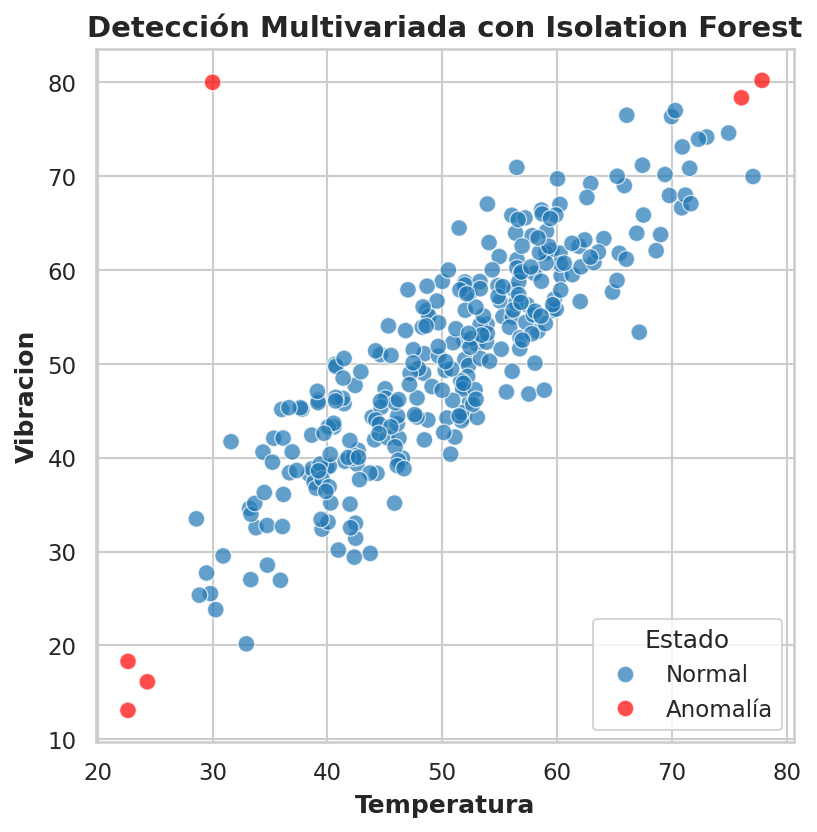

In [16]:
# Instanciamos el algoritmo (le pedimos que asuma que el ~2% de los datos son anomalías)
iso_forest = IsolationForest(contamination=0.02, random_state=42)

# Ajustamos y predecimos en el mismo paso (EDA puro, no estamos entrenando un modelo predictivo aún)
df_motor['Anomalia_IF'] = iso_forest.fit_predict(df_motor[['Temperatura', 'Vibracion']])

# Isolation Forest devuelve -1 para anomalías y 1 para datos normales
df_motor['Estado'] = df_motor['Anomalia_IF'].map({1: 'Normal', -1: 'Anomalía'})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_motor, x='Temperatura', y='Vibracion', hue='Estado',
                palette={'Normal': '#1f77b4', 'Anomalía': 'red'}, alpha=0.7)
plt.title("Detección Multivariada con Isolation Forest")
plt.show()

El algoritmo detectó perfectamente nuestro punto rojo (y un par de puntos más en los extremos de la distribución que requerían pocos cortes para ser aislados). 

**NOTA**: La cantidad de "puntos encontrados", se vincula directamente con el porcentaje de anomalías proporcionado (~2%). Hace falta criterio para ajustar los hiperparámetros de los algoritmos y lograr resultados esperados. Lo vemos más adelante...

> ⚠️ **El Peligro de Borrar a Ciegas:**
 Encontrar una anomalía no significa que debas borrarla. Si es un error de sensor, se borra o imputa. Pero si es una transacción fraudulenta o una falla real del motor, **¡esa anomalía es exactamente lo que el negocio quiere predecir!** Borrarla destruiría el valor del dataset.

## 3. Anomalías vs. Ruido Puro



Existe una confusión común en el análisis de datos: creer que una variable que no se correlaciona con nada es una "anomalía". En realidad, suele ser **Ruido Puro**.

- **Anomalía:** Es una ruptura en una estructura existente. (Aporta información crítica).
- **Ruido Puro:** Es la ausencia total de estructura. (Destruye información).

¿Qué pasa si a nuestro dataset perfecto le agregamos una columna de ruido aleatorio (ej. el ID de la máquina, o un sensor roto que tira números al azar)?



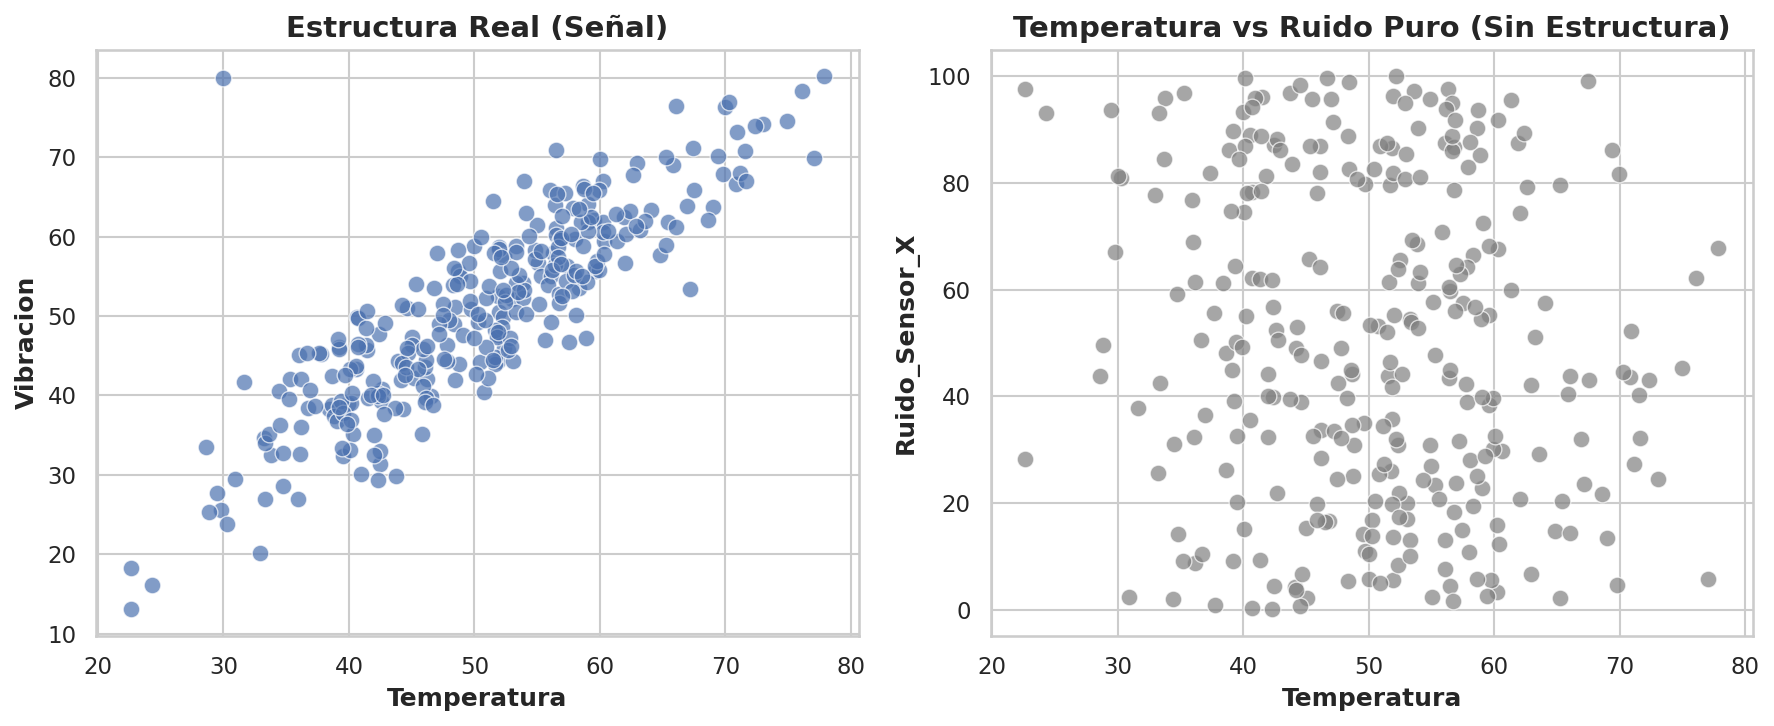

In [17]:
# Agregamos una variable de ruido puro (distribución uniforme aleatoria)
df_motor['Ruido_Sensor_X'] = np.random.uniform(0, 100, size=len(df_motor))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: La estructura real
sns.scatterplot(data=df_motor, x='Temperatura', y='Vibracion', ax=axes[0], alpha=0.7)
axes[0].set_title("Estructura Real (Señal)")

# Gráfico 2: El ruido
sns.scatterplot(data=df_motor, x='Temperatura', y='Ruido_Sensor_X', ax=axes[1], color='gray', alpha=0.7)
axes[1].set_title("Temperatura vs Ruido Puro (Sin Estructura)")

plt.tight_layout()
plt.show()

**Análisis de Ingeniería:**

Observar el gráfico de la derecha. No hay patrones, no hay tendencias, no hay agrupaciones. Es una nube de puntos dispersa uniformemente (o casi, habría que chequearlo en la realidad, pero ahora sabemos que es así porque lo generamos así).

Si se incluyen variables de "Ruido Puro" en un modelo de Machine Learning (especialmente en árboles de decisión profundos), el algoritmo intentará desesperadamente encontrar un patrón donde no lo hay. Terminará memorizando el ruido (Sobreajuste u *Overfitting*), y cuando se lo lleve a producción, fallará miserablemente.

**¿Cómo identificar el ruido en el EDA?**
1. Correlación cercana a cero con TODAS las demás variables y con el *target*.
2. Al graficarlo en *scatter plots* contra otras variables, genera "cuadrados" o "nubes" sin forma geométrica definida.
3. La Información Mutua (*Mutual Information*, vista en el *notebook* de [Análisis de Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb)) con el *target* es cero.


## Resultados y Discusión


En este *notebook* elevamos nuestro nivel de análisis:
1. Comprobamos que mirar las variables de a una (univariado) nos oculta los problemas más graves del mundo real.
2. Entendimos que algoritmos geométricos como *Isolation Forest* (*lo vemos en profundidad más adelante*) nos permiten encontrar puntos aislados en espacios de múltiples dimensiones sin necesidad de graficarlos .
3. Aprendimos a diferenciar visualmente una estructura de datos real frente a una variable de ruido puro, desarrollando el criterio para descartar columnas inútiles antes del modelado.

## Conexiones y Próximos Pasos


- ➡️ **Siguiente:** Ya sabemos encontrar anomalías (eventos raros). Pero, ¿qué pasa si nuestro objetivo es predecir una clase entera que es muy rara (ej. el 1% de los pacientes tiene una enfermedad)? Lo abordamos en [Manejo de Datos Desbalanceados](08_manejo_de_datos_desbalanceados.ipynb).
- 🔄 **Relacionado:** Si se tienen demasiadas variables y se sospecha que muchas son ruido, recordar que se puede comprimir el espacio usando [Reducción de Dimensionalidad (PCA)](06_reduccion_dimensionalidad_pca.ipynb).



## Referencias


1. Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation Forest*. In 2008 Eighth IEEE International Conference on Data Mining.
2. [Documentación de IsolationForest (Scikit-Learn)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)

---


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
